# Implement Naive bayes Classifier Based on **Bayes Theorem** 
to compute the probability of a message being spam or ham based on word frequencies trains the model on labeled data, evaluates its performance and predicts the class of new unseen messages

In [17]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# CountVectorizer converts text into numbers based on how many times each word appears.
# Seaborn is used to create statistical visualizations.

In [18]:
# load only columns v1 : whether the message is spam or not , v2 : the actual message 
df = pd.read_csv("CSVdata/spam.csv", encoding='latin-1')[['v1', 'v2']]
# Rename the columns
df.columns = ['Label', 'Message']
# Convert ham and spam into numbers
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

print(df.head())

   Label                                            Message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [19]:
X = df['Message']
y = df['Label']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Machine learning models cannot process raw text
# CountVectorizer converts text into word frequency vectors
vectorizer=CountVectorizer()
X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)


# Naive Bayes Models

Naive Bayes has different versions depending on the **type of data/features** we are working with.

The three common types are:

- **Multinomial Naive Bayes** → Count/Frequency data
- **Gaussian Naive Bayes** → Continuous numerical data
- **Categorical Naive Bayes** → Categorical data

---

<details>
<summary><strong>1. Multinomial Naive Bayes</strong></summary>

### What is it?

**Multinomial Naive Bayes** is a Naive Bayes algorithm that works well with **count or frequency data**.

It is especially useful for **text classification**.

### Example

Suppose we have an email:

```text
"Free money! Free prize!"

In [22]:
# It is a Naive Bayes algorithm designed mainly for discrete/count data.
# That's why it works very well with text classification.
# it called multinmial Because it works with counts of different categories/events
# MultinomialNB is a good choice when your features represent counts or frequencies.
nb_model=MultinomialNB()
nb_model.fit(X_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [23]:
y_pred = nb_model.predict(X_test_vec)

Accuracy: 98.39%


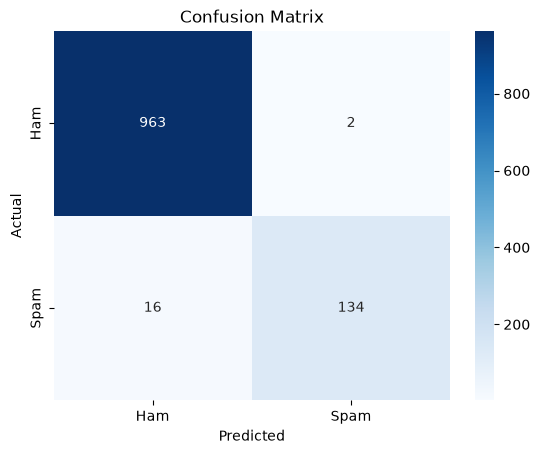

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

In [25]:
new_messages = [
    "Congratulations! You won a free ticket.",
    "Hey, are we still meeting today?"
]

new_vec = vectorizer.transform(new_messages)
predictions = nb_model.predict(new_vec)

for msg, pred in zip(new_messages, predictions):
    label = "Spam" if pred == 1 else "Ham"
    print(f"Message: '{msg}' => Prediction: {label}")

Message: 'Congratulations! You won a free ticket.' => Prediction: Spam
Message: 'Hey, are we still meeting today?' => Prediction: Ham
